# Практическое задание по нейронным сетям

## Часть 1: Настройка окружения и подготовка

In [18]:
# Установка необходимых библиотек
#!pip install tensorflow keras numpy matplotlib seaborn pandas scikit-learn plotly

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Activation
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad
from tensorflow.keras.regularizers import l2
import tensorflow as tf

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


### Подготовка датасетов

In [20]:
# Датасет 1: Бинарная классификация (Moons)
X1, y1 = make_moons(n_samples=1000, noise=0.2, random_state=42)
X1 = StandardScaler().fit_transform(X1)

# Датасет 2: Мультиклассовая классификация (5 классов)
X2, y2 = make_classification(n_samples=1000, n_features=20, n_informative=15, n_classes=5, random_state=42)
X2 = StandardScaler().fit_transform(X2)
y2_cat = tf.keras.utils.to_categorical(y2)

# Датасет 3: MNIST
(X3_train_full, y3_train_full), (X3_test, y3_test) = mnist.load_data()
X3_train_full = X3_train_full.astype('float32') / 255.0
X3_test = X3_test.astype('float32') / 255.0
y3_train_full_cat = tf.keras.utils.to_categorical(y3_train_full)
y3_test_cat = tf.keras.utils.to_categorical(y3_test)

## Часть 2: Построение и анализ архитектур
### Задача 2.1: Исследование глубины сети

In [21]:
def build_shallow():
    input_tensor = tf.keras.Input(shape=(X1.shape[1],))
    model = Sequential([input_tensor, Dense(16, activation='relu'), Dense(1, activation='sigmoid')])
    return model

def build_medium():
    input_tensor = tf.keras.Input(shape=(X1.shape[1],))
    model = Sequential([
        input_tensor,
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_deep():
    input_tensor = tf.keras.Input(shape=(X1.shape[1],))
    model = Sequential([
        input_tensor,
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def build_wide():
    input_tensor = tf.keras.Input(shape=(X1.shape[1],))
    model = Sequential([input_tensor, Dense(256, activation='relu'), Dense(1, activation='sigmoid')])
    return model

models = {
    "Мелкая": build_shallow(),
    "Средняя": build_medium(),
    "Глубокая": build_deep(),
    "Широкая": build_wide()
}

comparison_data = []
for name, model in models.items():
    params = model.count_params()
    # Примерный расчет памяти (float32 = 4 байта)
    memory = (params * 4) / 1024  # в КБ
    comparison_data.append({"Название": name, "Параметры": params, "Память (КБ)": round(memory, 2)})
    print(f"--- {name} сеть ---")
    model.summary()

df_params = pd.DataFrame(comparison_data)
display(df_params)

--- Мелкая сеть ---


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_104 (Dense)               │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

,Название,Параметры,Память (КБ)
0,Мелкая,65,0.25
1,Средняя,2817,11.00
2,Глубокая,8033,31.38
3,Широкая,1025,4.00


Вывод:  Увеличение количества слоев (глубины) позволяет модели выявлять более сложные иерархические зависимости в данных, однако это значительно увеличивает количество обучаемых параметров и риск переобучения. Широкие сети (много нейронов в одном слое) быстрее обучаются на простых данных, но менее эффективны в обобщении, чем глубокие архитектуры при сопоставимом количестве параметров.

### Задача 2.2: Исследование функций активации

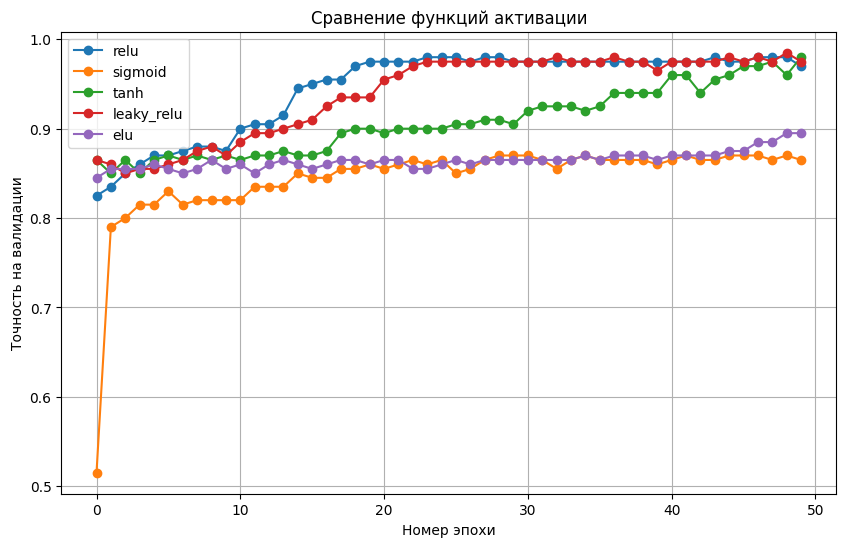

In [22]:
activations = ['relu', 'sigmoid', 'tanh', 'leaky_relu', 'elu']
histories = {}

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

for act in activations:
    input_tensor = tf.keras.Input(shape=(2,))
    model = Sequential([
        input_tensor,
        Dense(64, activation=act),
        Dense(32, activation=act),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    histories[act] = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, verbose=0)

plt.figure(figsize=(10, 6))
for act, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=act, marker='o')
plt.title('Сравнение функций активации')
plt.xlabel('Номер эпохи')
plt.ylabel('Точность на валидации')
plt.legend()
plt.grid(True)
plt.show()

#### График с ползунком (Decision Boundary)
Для визуализации изменения границы решения в процессе обучения используем Plotly.

In [23]:
def get_decision_boundary(model, X):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)
    return xx, yy, Z

act = 'relu'
input_tensor = tf.keras.Input(shape=(2,))
model = Sequential([input_tensor, Dense(64, activation=act), Dense(32, activation=act), Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy')

frames = []
for epoch in range(0, 51, 10):
    if epoch > 0: model.fit(X_train, y_train, epochs=10, verbose=0)
    xx, yy, Z = get_decision_boundary(model, X1)
    frames.append(go.Frame(data=[go.Contour(x=xx[0], y=yy[:,0], z=Z, colorscale='RdBu', opacity=0.8)], name=str(epoch)))

fig = go.Figure(
    data=[go.Contour(x=xx[0], y=yy[:,0], z=frames[0].data[0].z, colorscale='RdBu', opacity=0.8)],
    layout=go.Layout(
        title=f"Изменение границы решения ({act})",
        xaxis_title="Признак 1",   # подпись оси X
        yaxis_title="Признак 2",   # подпись оси Y
        updatemenus=[dict(type="buttons", buttons=[dict(label="Play", method="animate", args=[None])])]
    ),
    frames=frames
)

sliders = [dict(steps=[dict(method='animate', args=[[f.name], dict(mode='immediate', frame=dict(duration=300, redraw=True), transition=dict(duration=0))], label=f.name) for f in frames])]
fig.update_layout(sliders=sliders)
fig.show()

**Вывод по активациям:**
ReLU обычно обучается быстрее из-за отсутствия затухания градиентов в положительной области. Sigmoid и Tanh могут страдать от проблемы затухающих градиентов при глубоких архитектурах.

## Часть 3: Диагностика процесса обучения
### Задача 3.1: Анализ кривых обучения

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9221 - loss: 0.2711 - val_accuracy: 0.9521 - val_loss: 0.1601
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9652 - loss: 0.1137 - val_accuracy: 0.9672 - val_loss: 0.1164
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9760 - loss: 0.0769 - val_accuracy: 0.9718 - val_loss: 0.0971
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9821 - loss: 0.0584 - val_accuracy: 0.9737 - val_loss: 0.0919
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9863 - loss: 0.0450 - val_accuracy: 0.9704 - val_loss: 0.1049
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9745 - val_loss: 0.0998
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9912 - loss: 0.0270 - val_accuracy: 0.9750 - val_loss: 0.0982
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0264 - 

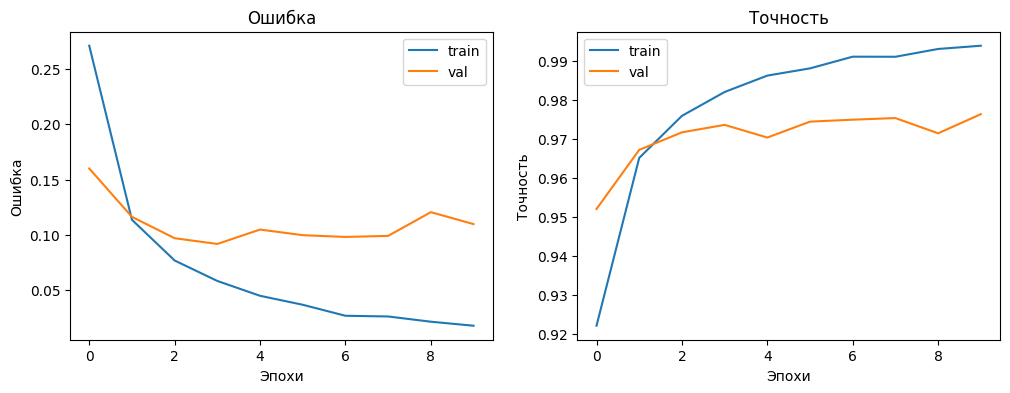

In [24]:
# Обучение на MNIST (Датасет 3)
input_tensor = tf.keras.Input(shape=(28, 28))
model_mnist = Sequential([
    input_tensor,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mnist = model_mnist.fit(X3_train_full, y3_train_full_cat, validation_split=0.2, epochs=10, verbose=1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['loss'], label='train')
plt.plot(history_mnist.history['val_loss'], label='val')
plt.title('Ошибка')
plt.xlabel('Эпохи')
plt.ylabel('Ошибка')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['accuracy'], label='train')
plt.plot(history_mnist.history['val_accuracy'], label='val')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

#### Анализ переобучения (Размер выборки и Регуляризация)

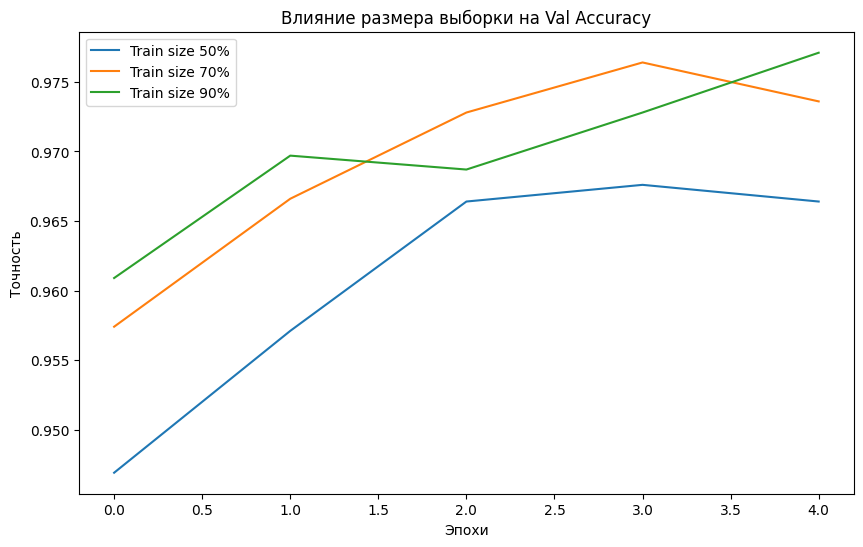

In [25]:
splits = [0.5, 0.7, 0.9]
plt.figure(figsize=(10, 6))
for s in splits:
    X_s, _, y_s, _ = train_test_split(X3_train_full, y3_train_full_cat, train_size=s, random_state=42)
    m = tf.keras.models.clone_model(model_mnist)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_s, y_s, epochs=5, verbose=0, validation_data=(X3_test, y3_test_cat))
    plt.plot(h.history['val_accuracy'], label=f'Train size {int(s*100)}%')

plt.title('Влияние размера выборки на Val Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

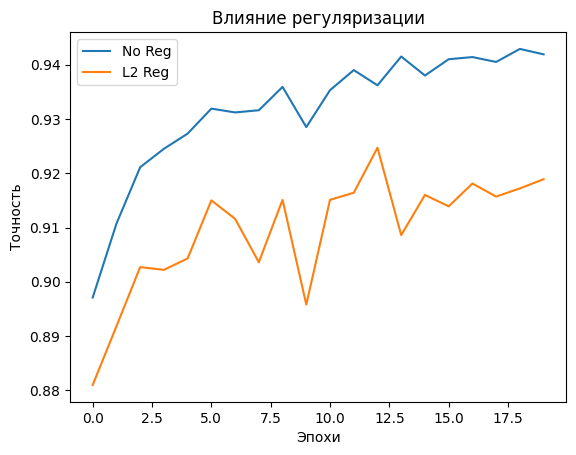

In [26]:
# Регуляризация
def build_reg(use_reg=False):
    reg = l2(0.01) if use_reg else None
    input_tensor = tf.keras.Input(shape=(28, 28))
    return Sequential([
        input_tensor,
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=reg),
        Dense(10, activation='softmax')
    ])

h_no_reg = build_reg(False)
h_no_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
res_no_reg = h_no_reg.fit(X3_train_full[:5000], y3_train_full_cat[:5000], epochs=20, verbose=0, validation_data=(X3_test, y3_test_cat))

h_reg = build_reg(True)
h_reg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
res_reg = h_reg.fit(X3_train_full[:5000], y3_train_full_cat[:5000], epochs=20, verbose=0, validation_data=(X3_test, y3_test_cat))

plt.plot(res_no_reg.history['val_accuracy'], label='No Reg')
plt.plot(res_reg.history['val_accuracy'], label='L2 Reg')
plt.title('Влияние регуляризации')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

Вывод: Точность модели напрямую зависит от объема обучающей выборки: при малом количестве данных наблюдается высокая дисперсия и переобучение. Использование L2-регуляризации позволяет сгладить веса модели, уменьшая разрыв между точностью на обучающей и валидационной выборках, что критично для работы с реальными данными

### Задача 3.2: Оптимизаторы

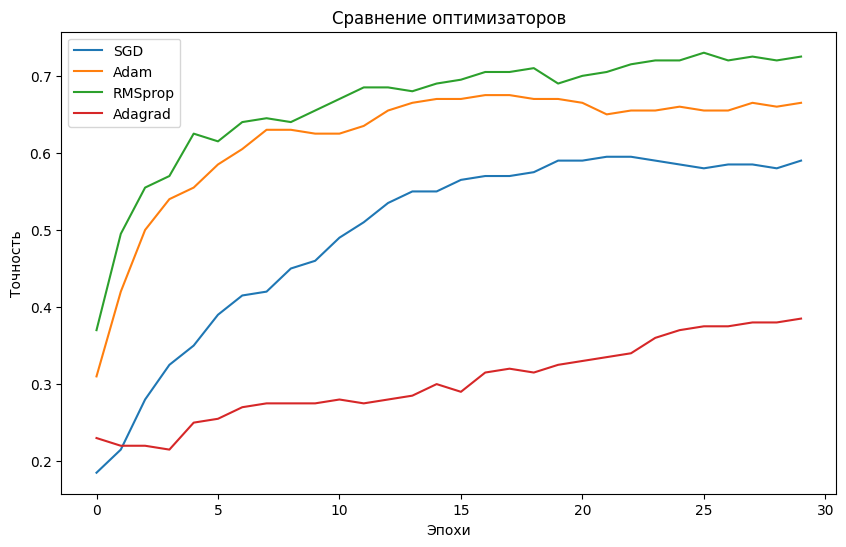

In [27]:
opts = {'SGD': SGD(), 'Adam': Adam(), 'RMSprop': RMSprop(), 'Adagrad': Adagrad()}
plt.figure(figsize=(10, 6))

for name, opt in opts.items():
    input_tensor = tf.keras.Input(shape=(20,))
    m = Sequential([input_tensor, Dense(64, activation='relu'), Dense(32, activation='relu'), Dense(5, activation='softmax')])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X2, y2_cat, epochs=30, verbose=0, validation_split=0.2)
    plt.plot(h.history['val_accuracy'], label=name)

plt.title('Сравнение оптимизаторов')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

Вывод: Адаптивные методы, такие как Adam и RMSprop, демонстрируют наиболее стабильную и быструю сходимость по сравнению с классическим SGD, так как они автоматически корректируют скорость обучения для каждого параметра. Adagrad эффективен на разреженных данных, но может слишком быстро снижать скорость обучения на плотных выборках.

## Часть 4: Регуляризация и Batch Normalization

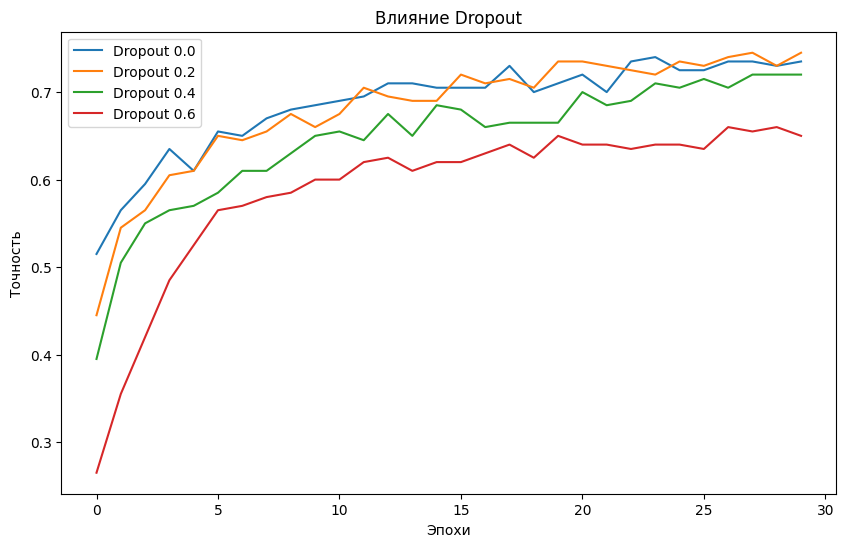

In [28]:
dropouts = [0.0, 0.2, 0.4, 0.6]
plt.figure(figsize=(10, 6))
for d in dropouts:
    input_tensor = tf.keras.Input(shape=(20,))
    m = Sequential([
        input_tensor,
        Dense(128, activation='relu'),
        Dropout(d),
        Dense(64, activation='relu'),
        Dropout(d),
        Dense(5, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X2, y2_cat, epochs=30, verbose=0, validation_split=0.2)
    plt.plot(h.history['val_accuracy'], label=f'Dropout {d}' )

plt.title('Влияние Dropout')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

Вывод: Метод Dropout эффективно борется с переобучением, заставляя нейроны обучаться более устойчивым признакам. Оптимальное значение (обычно 0.2–0.4) повышает точность на валидации, однако слишком высокий коэффициент (0.6 и выше) приводит к недообучению и замедлению процесса.

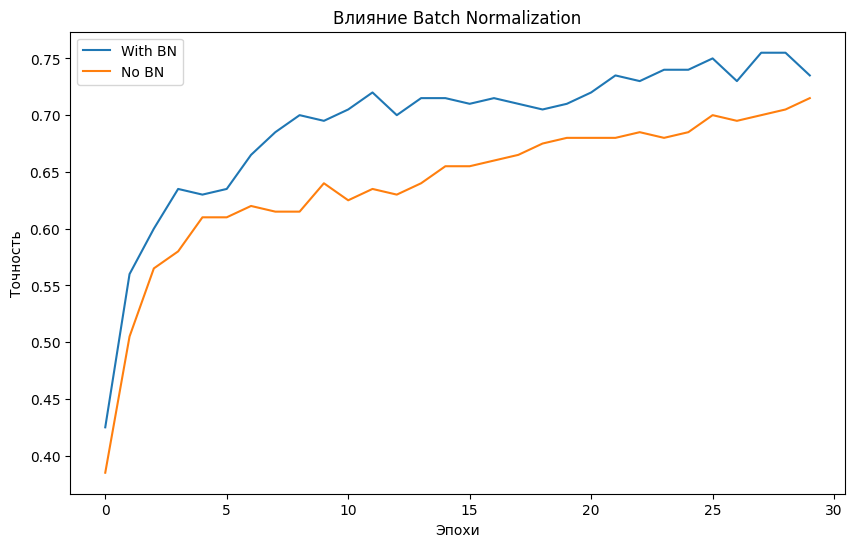

In [29]:
def build_bn(use_bn=False):
    input_tensor = tf.keras.Input(shape=(20,))
    m = Sequential()
    m.add(input_tensor)
    m.add(Dense(128))
    if use_bn: m.add(BatchNormalization())
    m.add(Activation('relu'))
    m.add(Dense(5, activation='softmax'))
    return m

plt.figure(figsize=(10, 6))
for use_bn in [True, False]:
    m = build_bn(use_bn)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X2, y2_cat, epochs=30, verbose=0, validation_split=0.2)
    plt.plot(h.history['val_accuracy'], label='With BN' if use_bn else 'No BN')

plt.title('Влияние Batch Normalization')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()

Вывод: Применение Batch Normalization значительно ускоряет обучение и делает модель менее чувствительной к начальной инициализации весов. Это позволяет использовать более высокие значения скорости обучения (learning rate) и обеспечивает дополнительный эффект регуляризации, улучшая итоговую точность модели.

# Контрольные вопросы

1. `Почему ReLU стала стандартом для скрытых слоёв?` 
   Потому что она простая, вычисляется быстро и меньше страдает от затухания градиента, чем sigmoid и tanh. За счёт этого глубокие сети обучаются стабильнее.
2. `Как выбрать оптимальное количество нейронов в слое?`
   Точного правила нет: обычно подбирают экспериментально. Мало нейронов — модель недообучается, слишком много — переобучается и растёт время обучения. Часто начинают со средних значений вроде 32, 64, 128.
3. `Когда использовать Early Stopping?`
   Когда нужно остановить обучение в момент, где валидационная ошибка перестаёт улучшаться. Это полезно, если модель начинает переобучаться.
4. `Почему BatchNorm ускоряет обучение?`
   Потому что нормализует значения внутри сети, из-за чего обучение становится стабильнее, можно использовать больший learning rate, и сеть сходится быстрее.
5. `Какие методы борьбы с переобучением наиболее эффективны для MLP?`
   Чаще всего это Early Stopping, Dropout, L2-регуляризация, BatchNorm, увеличение объёма данных или аугментация, уменьшение сложности модели